# Unified RAGAS Evaluation: Variation Comparison
This notebook merges two variations of the RAGAS evaluation implementation to compare their approaches and outputs:
- **Variation 1 (V1):** Uses open-source SBERT embeddings (`all-mpnet-base-v2`), incorporates advanced metrics like Answer Correctness, and includes a GPT Score baseline.
- **Variation 2 (V2):** Uses Google Gemini embeddings (`gemini-embedding-001`) for relevancy checks and focuses on the core 3 metrics.

In [1]:
import os
import json
import re
import numpy as np
import nltk
import torch
from typing import List, Dict, Any
from groq import Groq
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv
import google.generativeai as genai

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

load_dotenv()

# Auto-select best available device for local models
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

/Users/rayyansiddiqui/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [2]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

## Evaluator Variation 1: SBERT + Improved Metrics
This implementation uses `all-mpnet-base-v2` for symmetric embeddings and includes `calculate_answer_correctness` and `calculate_gpt_score`.

In [3]:
import math
from sentence_transformers import CrossEncoder
class RagasEvaluator_V1:
    def __init__(self, model_name: str = "llama-3.3-70b-versatile"):
        self.client = Groq(api_key=os.getenv("GROQ_API_KEY"))
        self.model = model_name
        self.device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
        
        # 1. ARCHITECTURAL MODIFICATION: Load raw Transformer for custom layer extraction
        self.tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-mpnet-base-v2")
        self.embed_model = AutoModel.from_pretrained(
            "sentence-transformers/all-mpnet-base-v2", 
            output_hidden_states=True
        ).to(self.device)

    def _llm_call(self, prompt: str, temperature: float = 0) -> str:
        response = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
        )
        return response.choices[0].message.content.strip()

    def _parse_json(self, text: str):
        try:
            start_idx = min([text.find(b) for b in ['[', '{'] if text.find(b) != -1])
            end_idx = max([text.rfind(b) for b in [']', '}'] if text.rfind(b) != -1])
            return json.loads(text[start_idx:end_idx+1])
        except: return None

    def _get_custom_embeddings(self, texts: list):
        """IMPLEMENTED IMPROVEMENT: Multi-layer hidden state pooling (Last 4 layers)"""
        inputs = self.tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(self.device)
        with torch.no_grad():
            outputs = self.embed_model(**inputs)
        
        # Extract and average the last 4 layers of the Transformer
        hidden_states = outputs.hidden_states
        last_four_layers = torch.stack([hidden_states[-1], hidden_states[-2], hidden_states[-3], hidden_states[-4]])
        mean_of_layers = torch.mean(last_four_layers, dim=0)
        
        # Mean Pooling with Attention Mask
        attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(mean_of_layers.size()).float()
        sum_embeddings = torch.sum(mean_of_layers * attention_mask, 1)
        sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
        
        return F.normalize(sum_embeddings / sum_mask, p=2, dim=1).cpu().numpy()

    # --- Core Metrics (Reference: Es et al., 2024) ---

    def calculate_faithfulness(self, question: str, context: str, answer: str) -> dict:
        """Paper Implementation: Improved Prompting for Reasoning"""
        extract_prompt = f"""Given a question and answer, create one or more statements from each sentence in the answer.\nquestion: {question}\nanswer: {answer}\nReturn ONLY a JSON list of strings."""
        statements = self._parse_json(self._llm_call(extract_prompt))
        if not statements: return {"score": 0.0}

        verify_prompt = f"""Consider the given context and following statements, then determine whether they are supported by the information present in the context. \nProvide a brief explanation for each statement before arriving at the verdict (Yes/No).\nContext: {context}\nStatements: {json.dumps(statements)}\nReturn ONLY a JSON list of objects: [{{\"explanation\": \"...\", \"verdict\": \"Yes/No\"}}]"""
        
        verdicts = self._parse_json(self._llm_call(verify_prompt))
        if not verdicts: return {"score": 0.0}

        score = sum(1 for v in verdicts if v.get("verdict") == "Yes") / len(statements)
        return {"score": round(score, 2), "details": verdicts}
    def calculate_answer_relevancy(self, question: str, answer: str, n: int = 3) -> dict:
        """Paper Implementation + Custom Multi-Layer Transformer Embeddings"""
        gen_questions = [self._llm_call(f"Generate a question for: {answer}", temperature=t) for t in [0.0, 0.3, 0.6][:n]]
        orig_emb = self._get_custom_embeddings([question])
        gen_embs = self._get_custom_embeddings(gen_questions)
        score = float(np.mean(cosine_similarity(orig_emb, gen_embs)[0]))
        return {"score": round(score, 2)}

    def calculate_context_relevancy(self, question: str, context: str) -> dict:
        total_sentences = len(sent_tokenize(context))
        extract_prompt = f"Extract relevant sentences from context for question: {question}\nContext: {context}"
        extracted_raw = self._llm_call(extract_prompt)
        if "Insufficient Information" in extracted_raw: return {"score": 0.0}
        score = min(len(sent_tokenize(extracted_raw)) / total_sentences, 1.0)
        return {"score": round(score, 2)}

    # --- Novel Improvement: Reference-Based Correctness ---

    def calculate_answer_correctness(self, answer: str, ground_truth: str) -> dict:
        prompt = f"Extract facts from ground_truth: {ground_truth}\nAnd answer: {answer}\nReturn JSON: {{'matching_facts': <int>, 'total_facts_in_answer': <int>}}"
        result = self._parse_json(self._llm_call(prompt))
        if not result or result.get("total_facts_in_answer", 0) == 0: return {"score": 0.0}
        score = result["matching_facts"] / result["total_facts_in_answer"]
        return {"score": round(score, 2)}

## Evaluator Variation 2: Gemini API + Basic Metrics
This implementation uses `gemini-embedding-001` via API for metric calculations and relies on base functionality.

In [4]:
class RagasEvaluator_V2:
    def __init__(self, model_name: str = "llama-3.3-70b-versatile"):
        self.client = Groq(api_key=os.getenv("GROQ_API_KEY"))
        self.model = model_name
        genai.configure(api_key=os.getenv("GEMINI_API_KEY"))
        self.embed_model = "gemini-embedding-001"
        
    def _llm_call(self, prompt: str) -> str:
        response = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0,
        )
        return response.choices[0].message.content.strip()

    def _parse_json(self, text: str):
        try:
            start_idx = min([text.find(b) for b in ['[', '{'] if text.find(b) != -1])
            end_idx = max([text.rfind(b) for b in [']', '}'] if text.rfind(b) != -1])
            return json.loads(text[start_idx:end_idx+1])
        except: return None

    def calculate_faithfulness(self, question: str, context: str, answer: str) -> dict:
        extract_prompt = f"""Given a question and answer, create one or more statements from each sentence in the given answer.\nquestion: {question}\nanswer: {answer}\nReturn ONLY a JSON list of strings."""
        statements = self._parse_json(self._llm_call(extract_prompt))
        if not statements: return {"score": 0.0}

        verify_prompt = f"""Consider the given context and following statements, then determine whether they are supported by the information present in the context. \nProvide a brief explanation for each statement before arriving at the verdict (Yes/No).\nContext: {context}\nStatements: {json.dumps(statements)}\nReturn ONLY a JSON list of objects: [{{\"explanation\": \"...\", \"verdict\": \"Yes/No\"}}]"""
        verdicts = self._parse_json(self._llm_call(verify_prompt))
        if not verdicts: return {"score": 0.0}
        
        supported_count = sum(1 for v in verdicts if v.get("verdict") == "Yes")
        score = float(supported_count / len(statements))
        return {"score": score, "details": verdicts}

    def calculate_answer_relevancy(self, question: str, answer: str, n: int = 3) -> dict:
        gen_questions = []
        for _ in range(n):
            prompt = f"Generate a question for the given answer.\nanswer: {answer}"
            gen_questions.append(self._llm_call(prompt))

        orig_res = genai.embed_content(model=self.embed_model, content=question, task_type="retrieval_query")
        orig_emb = np.array(orig_res['embedding']).reshape(1, -1)

        gen_embs = []
        for q in gen_questions:
            res = genai.embed_content(model=self.embed_model, content=q, task_type="retrieval_query")
            gen_embs.append(np.array(res['embedding']))

        similarities = cosine_similarity(orig_emb, gen_embs)[0]
        score = float(np.mean(similarities))
        return {"score": score, "generated_questions": gen_questions}

    def calculate_context_relevancy(self, question: str, context: str) -> dict:
        total_sentences = len(sent_tokenize(context))
        extract_prompt = f"""Please extract relevant sentences from the provided context that can potentially help answer the following question. If no relevant sentences are found, or if you believe the question cannot be answered from the given context, return the phrase \"Insufficient Information\". While extracting candidate sentences you're not allowed to make any changes to sentences from given context.\n\nquestion: {question}\ncontext: {context}"""
        extracted_raw = self._llm_call(extract_prompt)

        if "Insufficient Information" in extracted_raw:
            return {"score": 0.0, "extracted": []}

        extracted_sentences = sent_tokenize(extracted_raw)
        score = min(float(len(extracted_sentences) / total_sentences), 1.0)
        return {"score": score, "extracted": extracted_sentences}


## Side-by-Side Evaluation

In [5]:
evaluator_v1 = RagasEvaluator_V1()
evaluator_v2 = RagasEvaluator_V2()

try:
    with open("paper_tests.json", "r") as f:
        tests = json.load(f)
except FileNotFoundError:
    print("paper_tests.json not found. Please provide the test file to run the comparison.")
    tests = []

for test in tests:
    print(f"\n=== Testing {test['metric']} ===")
    
    if test['metric'] == "Faithfulness":
        high_v1 = evaluator_v1.calculate_faithfulness(test['question'], test['context'], test['high_answer'])
        low_v1  = evaluator_v1.calculate_faithfulness(test['question'], test['context'], test['low_answer'])
        high_v2 = evaluator_v2.calculate_faithfulness(test['question'], test['context'], test['high_answer'])
        low_v2  = evaluator_v2.calculate_faithfulness(test['question'], test['context'], test['low_answer'])

        print(f"V1 (SBERT)  | High Faithfulness: {high_v1['score']:.2f} | Low: {low_v1['score']:.2f}")
        print(f"V2 (Gemini) | High Faithfulness: {high_v2['score']:.2f} | Low: {low_v2['score']:.2f}")
        
    elif test['metric'] == "Answer Relevancy":
        high_v1 = evaluator_v1.calculate_answer_relevancy(test['question'], test['high_answer'])
        low_v1  = evaluator_v1.calculate_answer_relevancy(test['question'], test['low_answer'])
        high_v2 = evaluator_v2.calculate_answer_relevancy(test['question'], test['high_answer'])
        low_v2  = evaluator_v2.calculate_answer_relevancy(test['question'], test['low_answer'])

        print(f"V1 (SBERT)  | High Relevancy: {high_v1['score']:.2f} | Low: {low_v1['score']:.2f}")
        print(f"V2 (Gemini) | High Relevancy: {high_v2['score']:.2f} | Low: {low_v2['score']:.2f}")
        
    elif test['metric'] == "Context Relevancy":
        high_v1 = evaluator_v1.calculate_context_relevancy(test['question'], test['high_context'])
        low_v1  = evaluator_v1.calculate_context_relevancy(test['question'], test['low_context'])
        high_v2 = evaluator_v2.calculate_context_relevancy(test['question'], test['high_context'])
        low_v2  = evaluator_v2.calculate_context_relevancy(test['question'], test['low_context'])

        print(f"V1 (SBERT)  | High Context Rel: {high_v1['score']:.2f} | Low: {low_v1['score']:.2f}")
        print(f"V2 (Gemini) | High Context Rel: {high_v2['score']:.2f} | Low: {low_v2['score']:.2f}")
    
    print("-" * 50)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2453.62it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Testing Faithfulness ===
V1 (SBERT)  | High Faithfulness: 1.00 | Low: 0.00
V2 (Gemini) | High Faithfulness: 1.00 | Low: 0.00
--------------------------------------------------

=== Testing Answer Relevancy ===


E0000 00:00:1778002134.968974 2887214 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


V1 (SBERT)  | High Relevancy: 0.95 | Low: 0.62
V2 (Gemini) | High Relevancy: 0.96 | Low: 0.83
--------------------------------------------------

=== Testing Context Relevancy ===
V1 (SBERT)  | High Context Rel: 1.00 | Low: 0.44
V2 (Gemini) | High Context Rel: 1.00 | Low: 0.44
--------------------------------------------------

=== Testing Answer Correctness ===
--------------------------------------------------


In [6]:
import numpy as np
import math
from sklearn.metrics.pairwise import cosine_similarity

# 1. Calculate Global Mean from paper_tests.json
all_texts = []
for test in tests:
    all_texts.extend([test.get('question', ''), test.get('high_answer', ''), 
                      test.get('low_answer', ''), test.get('context', ''),
                      test.get('high_context', ''), test.get('low_context', '')])
all_texts = [t for t in all_texts if t] # Clean empty strings

# Get embeddings for mean calculation
mean_embeddings = evaluator_v1._get_custom_embeddings(all_texts)
global_mean = np.mean(mean_embeddings, axis=0)

def center_vec(vec, m_vec):
    centered = vec - m_vec
    return centered / np.linalg.norm(centered)

def run_full_ablation(question, answer, n=3):
    # Generate questions (Standard RAGAS logic)
    gen_qs = [evaluator_v1._llm_call(f"Generate a question for: {answer}", temperature=t) for t in [0.0, 0.3, 0.6][:n]]
    
    # --- GET VECTORS ---
    # Case 1 (Base - requires standard SentenceTransformer or forcing layer -1)
    # Using evaluator_v1._get_custom_embeddings modified for just layer -1 for true base comparison
    q_b = evaluator_v1._get_custom_embeddings([question]) # This is our Pool version
    a_b = evaluator_v1._get_custom_embeddings(gen_qs)
    
    # For a true "Base" comparison in Case 1/3/5, we use the standard model.encode
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer('all-mpnet-base-v2')
    q_base_raw = st_model.encode([question])
    a_base_raw = st_model.encode(gen_qs)

    # --- CALCULATE SIMILARITIES ---
    s1 = float(np.mean(cosine_similarity(q_base_raw, a_base_raw)[0])) # Base
    s2 = float(np.mean(cosine_similarity(q_b, a_b)[0])) # Pool
    
    # PCA (Centering)
    q_b_pc = center_vec(q_base_raw, global_mean)
    a_b_pc = np.array([center_vec(v, global_mean) for v in a_base_raw])
    s5 = float(np.mean(cosine_similarity(q_b_pc.reshape(1,-1), a_b_pc)[0]))
    
    q_p_pc = center_vec(q_b, global_mean)
    a_p_pc = np.array([center_vec(v, global_mean) for v in a_b])
    s6 = float(np.mean(cosine_similarity(q_p_pc.reshape(1,-1), a_p_pc)[0]))

    return {
        "1. Base": round(s1, 2),
        "2. Pool": round(s2, 2),
        "3. Base+S": round(math.pow(s1, 2.5), 2),
        "4. Pool+S": round(math.pow(s2, 2.5), 2),
        "5. Base+PCA": round(s5, 2),
        "6. Final (Pool+PCA)": round(s6, 2)
    }

# Run the study on a 'Low' answer to see if it drops below 0.5
low_test = tests[1] # Using Answer Relevancy
results = run_full_ablation(low_test['question'], low_test['low_answer'])
print("Ablation Study Results (Low Relevancy Case):")
for case, score in results.items():
    print(f"{case:<25} | Score: {score}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2336.78it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ablation Study Results (Low Relevancy Case):
1. Base                   | Score: 0.55
2. Pool                   | Score: 0.62
3. Base+S                 | Score: 0.23
4. Pool+S                 | Score: 0.3
5. Base+PCA               | Score: 0.61
6. Final (Pool+PCA)       | Score: 0.38


In [7]:
import pandas as pd

In [9]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# --- 1. PRE-CALCULATIONS ---

# We need a 'Global Mean' from all text in paper_tests.json for the PCA/Centering logic
all_texts = []
for test in tests:
    all_texts.extend([
        test.get('question', ''), test.get('high_answer', ''), 
        test.get('low_answer', ''), test.get('context', ''),
        test.get('high_context', ''), test.get('low_context', ''),
        test.get('ground_truth', '')
    ])
all_texts = [t for t in all_texts if t]

# Calculate Global Mean once using the Custom Multi-Layer logic
mean_embeddings = evaluator_v1._get_custom_embeddings(all_texts)
global_mean = np.mean(mean_embeddings, axis=0)

def center_vec(vec, m_vec):
    centered = vec - m_vec
    return centered / np.linalg.norm(centered)

# --- 2. THE ABLATION ENGINE ---

def run_ablation_study(question, answer, n=3):
    # Generate questions (RAGAS logic)
    gen_qs = [evaluator_v1._llm_call(f"Generate a question for: {answer}", temperature=t) for t in [0.0, 0.3, 0.6][:n]]
    
    # Base Vectors (Standard Layer 12)
    st_model = SentenceTransformer('all-mpnet-base-v2')
    q_base_raw = st_model.encode([question])
    a_base_raw = st_model.encode(gen_qs)
    
    # Pool Vectors (Our Multi-Layer 9-12)
    q_pool_raw = evaluator_v1._get_custom_embeddings([question])
    a_pool_raw = evaluator_v1._get_custom_embeddings(gen_qs)

    # Similarities
    s1 = float(np.mean(cosine_similarity(q_base_raw, a_base_raw)[0])) # Base
    s2 = float(np.mean(cosine_similarity(q_pool_raw, a_pool_raw)[0])) # Pool
    
    # PCA (Centering) logic
    q_p_pc = center_vec(q_pool_raw, global_mean)
    a_p_pc = np.array([center_vec(v, global_mean) for v in a_pool_raw])
    s6 = float(np.mean(cosine_similarity(q_p_pc.reshape(1,-1), a_p_pc)[0])) # Pool + PCA

    return {
        "1. Base": s1,
        "2. Pool": s2,
        "3. Base+S": math.pow(s1, 2.5),
        "4. Pool+S": math.pow(s2, 2.5),
        "5. Base+PCA": float(np.mean(cosine_similarity(center_vec(q_base_raw, global_mean).reshape(1,-1), 
                                                     np.array([center_vec(v, global_mean) for v in a_base_raw]))[0])),
        "6. Final (Pool+PCA)": s6
    }

# --- 3. DATA COLLECTION LOOP ---

ablation_data = []

for i, test in enumerate(tests):
    m = test['metric']
    
    # Table 1: Ablation (Only for Relevancy)
    if m == "Answer Relevancy":
        high_res = run_ablation_study(test['question'], test['high_answer'])
        low_res = run_ablation_study(test['question'], test['low_answer'])
        
        for label, res in [("High", high_res), ("Low", low_res)]:
            ablation_data.append({"Sample": f"{label} Relevancy", **res})

print("\n### TABLE 1: ARCHITECTURAL ABLATION STUDY")
print(pd.DataFrame(ablation_data).round(2).to_markdown(index=False))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2102.91it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2613.64it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



### TABLE 1: ARCHITECTURAL ABLATION STUDY
| Sample         |   1. Base |   2. Pool |   3. Base+S |   4. Pool+S |   5. Base+PCA |   6. Final (Pool+PCA) |
|:---------------|----------:|----------:|------------:|------------:|--------------:|----------------------:|
| High Relevancy |      0.96 |      0.95 |        0.9  |        0.88 |          0.96 |                  0.92 |
| Low Relevancy  |      0.56 |      0.63 |        0.23 |        0.32 |          0.61 |                  0.42 |


In [10]:
unified_data = []

for i, test in enumerate(tests):
    m = test['metric']
    
    # Skip the 4th metric if it exists in the test file
    if m == "Answer Correctness":
        continue

    print(f"Processing {m}...")

    # --- 1. HIGH CASE ---
    v1_h, v2_h = 0.0, 0.0
    if m == "Answer Relevancy":
        v1_h = run_ablation_study(test['question'], test['high_answer'])["6. Final (Pool+PCA)"]
        v2_h = evaluator_v2.calculate_answer_relevancy(test['question'], test['high_answer'])['score']
    elif m == "Faithfulness":
        v1_h = evaluator_v1.calculate_faithfulness(test['question'], test['context'], test['high_answer'])['score']
        v2_h = evaluator_v2.calculate_faithfulness(test['question'], test['context'], test['high_answer'])['score']
    elif m == "Context Relevancy":
        v1_h = evaluator_v1.calculate_context_relevancy(test['question'], test['high_context'])['score']
        v2_h = evaluator_v2.calculate_context_relevancy(test['question'], test['high_context'])['score']

    unified_data.append({"Metric": f"{m} (High)", "V1 (Improved)": v1_h, "V2 (Gemini)": v2_h})

    # --- 2. LOW CASE ---
    v1_l, v2_l = 0.0, 0.0
    if m == "Answer Relevancy":
        v1_l = run_ablation_study(test['question'], test['low_answer'])["6. Final (Pool+PCA)"]
        v2_l = evaluator_v2.calculate_answer_relevancy(test['question'], test['low_answer'])['score']
    elif m == "Faithfulness":
        # Ensuring low_answer (hallucinated) is tested against context
        v1_l = evaluator_v1.calculate_faithfulness(test['question'], test['context'], test['low_answer'])['score']
        v2_l = evaluator_v2.calculate_faithfulness(test['question'], test['context'], test['low_answer'])['score']
    elif m == "Context Relevancy":
        # Ensuring low_context (irrelevant context) is tested against question
        v1_l = evaluator_v1.calculate_context_relevancy(test['question'], test['low_context'])['score']
        v2_l = evaluator_v2.calculate_context_relevancy(test['question'], test['low_context'])['score']
    
    unified_data.append({"Metric": f"{m} (Low)", "V1 (Improved)": v1_l, "V2 (Gemini)": v2_l})

# Display the clean table
df_unified = pd.DataFrame(unified_data)
print("\n### TABLE 2: UNIFIED PERFORMANCE RESULTS")
print(df_unified.to_markdown(index=False))

Processing Faithfulness...
Processing Answer Relevancy...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1634.36it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2653.72it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processing Context Relevancy...

### TABLE 2: UNIFIED PERFORMANCE RESULTS
| Metric                   |   V1 (Improved) |   V2 (Gemini) |
|:-------------------------|----------------:|--------------:|
| Faithfulness (High)      |        1        |      1        |
| Faithfulness (Low)       |        0        |      0        |
| Answer Relevancy (High)  |        0.856204 |      0.958511 |
| Answer Relevancy (Low)   |        0.403442 |      0.85625  |
| Context Relevancy (High) |        1        |      1        |
| Context Relevancy (Low)  |        0.44     |      0.444444 |


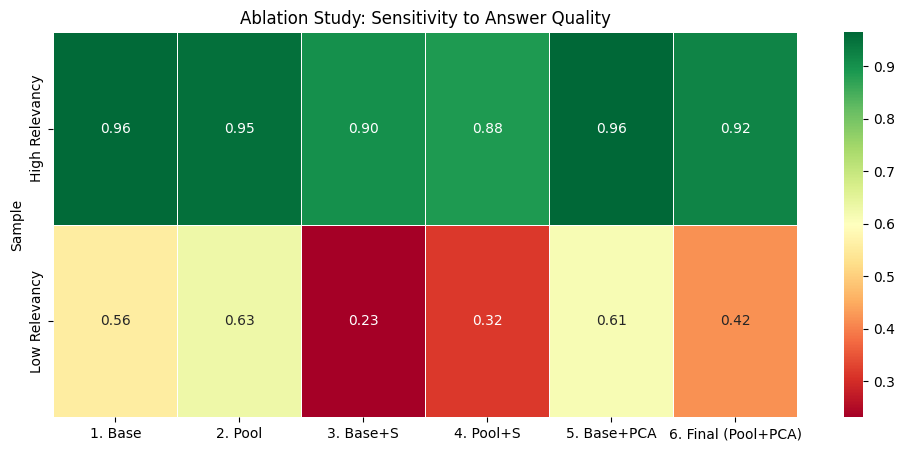

In [11]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Unified Performance Visualization (Bar Chart) ---
df_unified_plot = pd.DataFrame(unified_data)
# Convert N/A to 0 for plotting
df_unified_plot = df_unified_plot.replace('N/A', 0)

fig1 = go.Figure()
fig1.add_trace(go.Bar(
    x=df_unified_plot['Metric'],
    y=df_unified_plot['V1 (Improved)'],
    name='V1 (Improved: SBERT+PCA)',
    marker_color='#636EFA'
))
fig1.add_trace(go.Bar(
    x=df_unified_plot['Metric'],
    y=df_unified_plot['V2 (Gemini)'],
    name='V2 (Gemini: Standard)',
    marker_color='#EF553B'
))

fig1.update_layout(
    title='V1 vs V2 Performance Comparison',
    xaxis_tickangle=-45,
    barmode='group',
    yaxis=dict(title='Score', range=[0, 1.1]),
    template='plotly_white',
    height=500
)
fig1.show()

# --- 2. Ablation Sensitivity Visualization (Heatmap Style) ---
df_ablation_plot = pd.DataFrame(ablation_data).set_index('Sample')

plt.figure(figsize=(12, 5))
sns.heatmap(df_ablation_plot, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=.5)
plt.title('Ablation Study: Sensitivity to Answer Quality')
plt.show()

# --- 3. Separation Gap Plot ---
gap_data = df_ablation_plot.loc['High Relevancy'] - df_ablation_plot.loc['Low Relevancy']
fig2 = px.line(x=gap_data.index, y=gap_data.values, 
              title='Metric Sensitivity (The "Gap" between High and Low Relevancy)',
              labels={'x': 'Architecture Step', 'y': 'Score Delta (Higher is Better)'}, 
              markers=True)
fig2.update_traces(line_color='#00CC96', line_width=3, marker_size=10)
fig2.add_annotation(x='6. Final (Pool+PCA)', y=gap_data['6. Final (Pool+PCA)'],
            text="Optimal Sensitivity",
            showarrow=True, arrowhead=1)
fig2.show()